<a href="https://colab.research.google.com/github/alkhurayjah/Unit3_Project/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries and dataset downloads

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set_style("whitegrid")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaykhaaldawsari/jadarat-cleaned-data-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'jadarat-cleaned-data-csv' dataset.
Path to dataset files: /kaggle/input/jadarat-cleaned-data-csv


In [3]:
df = pd.read_csv( path + "/processed_dataset.csv")



---



#First data preview

In [4]:
df.head()

,job_title,job_date,comp_name,comp_type,comp_size,eco_activity,region,city,benefits,contract,positions,exper,gender,Salary
0,Secretary,2022-10-01,مؤسسة دمك للمقاولات العامة,1,SB,Construction and Real Estate,Eastern,BUQAYQ,0,1,1,0,1,4000.0
1,Salesperson,2022-10-03,شركة محمد سراج عطار وأخويه,1,SB,Trade and Retail,Makkah,JEDDAH,1,1,3,0,0,4000.0
2,Receptionist,2022-10-08,مركز شار لطب الاسنان,1,MA,Trade and Retail,Makkah,JEDDAH,1,1,2,4,1,4000.0
3,Accountant,2022-10-12,شركة اسواق بساتين القصيم,1,MB,Trade and Retail,Riyadh,AR RIYADH,1,1,10,0,2,4000.0
4,Secretary,2022-10-13,شركة السبائك الذهبية للمعادن الثمينة,1,SA,Trade and Retail,Makkah,JEDDAH,1,1,1,2,1,5000.0


In [5]:
df.shape

(1470, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_title     1470 non-null   object 
 1   job_date      1470 non-null   object 
 2   comp_name     1470 non-null   object 
 3   comp_type     1470 non-null   int64  
 4   comp_size     1470 non-null   object 
 5   eco_activity  1470 non-null   object 
 6   region        1470 non-null   object 
 7   city          1470 non-null   object 
 8   benefits      1470 non-null   int64  
 9   contract      1470 non-null   int64  
 10  positions     1470 non-null   int64  
 11  exper         1470 non-null   int64  
 12  gender        1470 non-null   int64  
 13  Salary        1470 non-null   float64
dtypes: float64(1), int64(6), object(7)
memory usage: 160.9+ KB


In [7]:
df.duplicated().sum()

np.int64(83)

In [8]:
df.isnull().sum()

,0
job_title,0
job_date,0
comp_name,0
comp_type,0
comp_size,0
eco_activity,0
region,0
city,0
benefits,0
contract,0


In [9]:
df.describe()

,comp_type,benefits,contract,positions,exper,gender,Salary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.996599,0.265306,0.985034,2.938776,1.278912,1.072789,5294.650340
std,0.058242,0.441646,0.121458,6.400864,1.879568,0.849142,2296.926479
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3000.000000
25%,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,4000.000000
50%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,4500.000000
75%,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,6000.000000
max,1.000000,1.000000,1.000000,50.000000,12.000000,2.000000,35000.000000


### 1. Data Description Insights
By utilizing the `describe()` function, we extracted valuable preliminary insights regarding the nature of the posted jobs:

* **Salary:** The average offered salary is **5,294 SAR**, starting from a minimum of **3,000 SAR** and reaching a maximum of **35,000 SAR**. We can observe that 50% of the jobs (the median) offer a salary of 4,500 SAR or less, indicating that most jobs target entry-level to mid-level positions.
* **Experience (`exper`):** The average required experience is **1.27 years**. Interestingly, 50% of the jobs (the median) do not require any prior experience (**0 years**), making this platform an excellent environment for fresh graduates.
* **Vacancies (`positions`):** On average, each job posting announces around **3 vacancies**, with some massive recruitment campaigns requesting up to **50 employees** in a single ad.

### 2. Categorical Data Encoding Guide
To maintain the dataset's efficiency for analysis and potential machine learning modeling, categorical columns are kept encoded as numbers. Here is what the numbers represent:
* **`comp_type` (Company Type):** `1` = Private Sector, `0` = Semi-Governmental. *(With a mean of 0.99, over 99% of jobs are in the private sector).*
* **`contract` (Contract Type):** `1` = Full-time, `0` = Remote. *(With a mean of 0.98, ~98.5% of jobs are full-time).*
* **`benefits` (Benefits):** `1` = Benefits offered, `0` = No benefits. *(Only ~26.5% of jobs offer additional benefits).*
* **`gender` (Gender):** `0` = Male, `1` = Female, `2` = Both.

---

### 3. Data Cleaning & Preprocessing Steps
Overall, the dataset is in **excellent condition** with absolutely no missing values (Nulls). The steps we will implement to prepare the data for analysis are:

1. **Drop Duplicates:** We detected **83 duplicated rows**. We will remove them to ensure the accuracy of our analysis and avoid any bias caused by reposted job ads.
2. **Data Type Formatting:** We will convert the `job_date` column from a text type (`Object`) to a date type (`Datetime`) to enable time-series analysis based on months or days.



---



#Data cleaning

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

,0
job_title,0
job_date,0
comp_name,0
comp_type,0
comp_size,0
eco_activity,0
region,0
city,0
benefits,0
contract,0


In [12]:
df['job_date'] = pd.to_datetime(df['job_date'])
df['year'] = df['job_date'].dt.year
df['month'] = df['job_date'].dt.month
df['day'] = df['job_date'].dt.day



---



#Column and relationship analysis & visualization

How many job titles?

In [22]:
print("There is a job title ",len(df["job_title"].value_counts()))
top_5 = df["job_title"].value_counts().head()
top_5

There is a job title  44


,count
job_title,
Analyst,222
Salesperson,188
Manager,126
Accountant,123
Technician,97


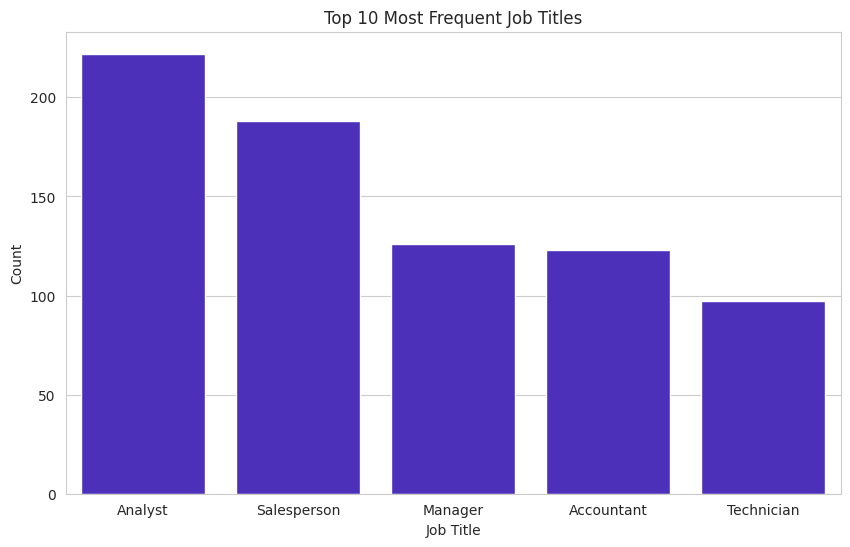

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(y=top_5.values, x=top_5.index,  color="#4019D1")

plt.title('Top 10 Most Frequent Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')

plt.show()

There are 44 job titles, the most common being "Analyst" and "Salesperson".

What are the highest average salaries for jobs?

In [15]:
top_salaries = df.groupby("job_title")["Salary"].mean().sort_values(ascending=False).head(10)
top_salaries

,Salary
job_title,
Pilot,35000.000000
CEO,9312.500000
Developer,8357.142857
Doctor,8000.000000
Engineer,7291.900000
HR Specialist,6586.607143
Electrician,6513.636364
Pharmacist,6500.000000
Dentist,6250.000000


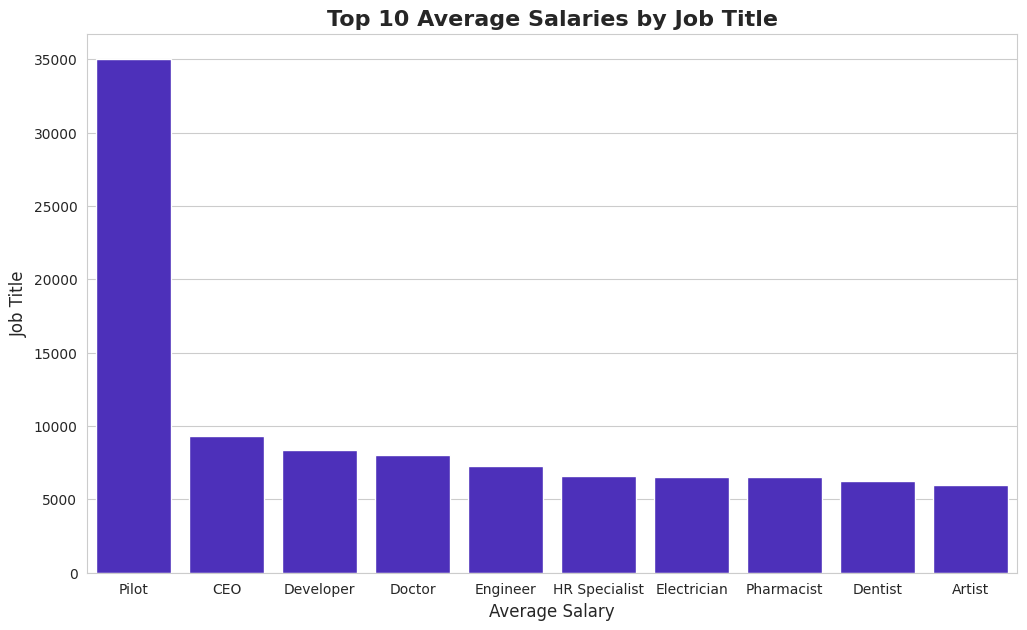

In [16]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(y=top_salaries.values, x=top_salaries.index , color="#4019D1" )



plt.title("Top 10 Average Salaries by Job Title", fontsize=16, fontweight='bold')
plt.xlabel("Average Salary", fontsize=12)
plt.ylabel("Job Title", fontsize=12)

plt.show()

Highest average CEO salary




---
